In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

c:\Users\AB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
file_path = r"C:\Users\AB\Downloads\archive (34)\training.1600000.processed.noemoticon.csv"

columns = [
    "Sentiment",
    "Tweet_ID",
    "Date",
    "Query",
    "User",
    "Tweet"
]


In [3]:
df = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=columns
)

In [4]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 records:")
print(df.head())

Dataset loaded successfully!
Shape: (1600000, 6)

First 5 records:
   Sentiment    Tweet_ID                          Date     Query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              User                                              Tweet  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [5]:

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing tweets
df = df.dropna(subset=["Tweet"])


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   Sentiment  1600000 non-null  int64
 1   Tweet_ID   1600000 non-null  int64
 2   Date       1600000 non-null  str  
 3   Query      1600000 non-null  str  
 4   User       1600000 non-null  str  
 5   Tweet      1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB
None

Missing Values:
Sentiment    0
Tweet_ID     0
Date         0
Query        0
User         0
Tweet        0
dtype: int64


In [6]:
def clean_text(text):

   
    text = str(text)

   
    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

   
    text = re.sub(r"@\w+", "", text)

   
    text = re.sub(r"#", "", text)

   
    text = re.sub(r"\brt\b", "", text)

    
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

print("\nCleaned Tweets:")
print(df[["Tweet", "Clean_Tweet"]].head())


Cleaned Tweets:
                                               Tweet  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                         Clean_Tweet  
0  a that s a bummer you shoulda got david carr o...  
1  is upset that he can t update his facebook by ...  
2  i dived many times for the ball managed to sav...  
3     my whole body feels itchy and like its on fire  
4  no it s not behaving at all i m mad why am i h...  


In [7]:

df = df[df["Clean_Tweet"].str.len() > 0]

print("\nDataset after cleaning:", df.shape)


Dataset after cleaning: (1596302, 7)



Sentiment Distribution:
Sentiment
0    798319
4    797983
Name: count, dtype: int64


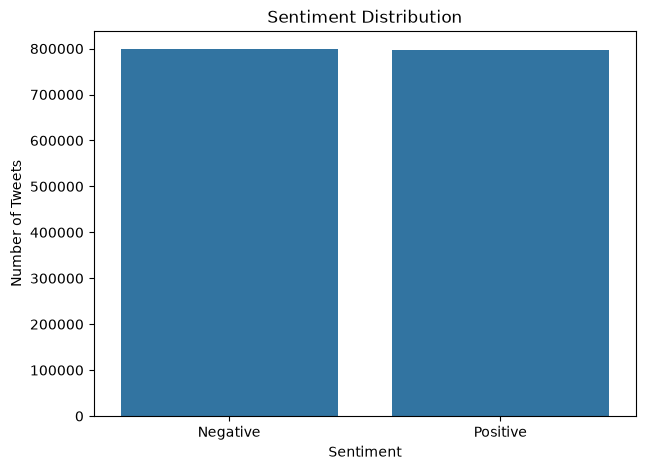

In [8]:
sentiment_counts = df["Sentiment"].value_counts()

print("\nSentiment Distribution:")
print(sentiment_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.show()

In [9]:
all_words = " ".join(df["Clean_Tweet"])

words = all_words.split()

word_counts = Counter(words)

# Remove common short words
filtered_words = {
    word: count
    for word, count in word_counts.items()
    if len(word) > 2
}

top_words = Counter(filtered_words).most_common(20)

print("\nTop 20 Most Frequent Words:")

for word, count in top_words:
    print(word, ":", count)


Top 20 Most Frequent Words:
the : 523867
and : 303620
you : 302229
for : 216373
that : 166015
have : 145643
but : 133526
just : 126969
with : 115333
not : 108706
was : 104660
this : 94572
now : 94000
can : 93780
good : 91343
day : 89560
all : 83578
out : 82254
get : 82172
like : 78573


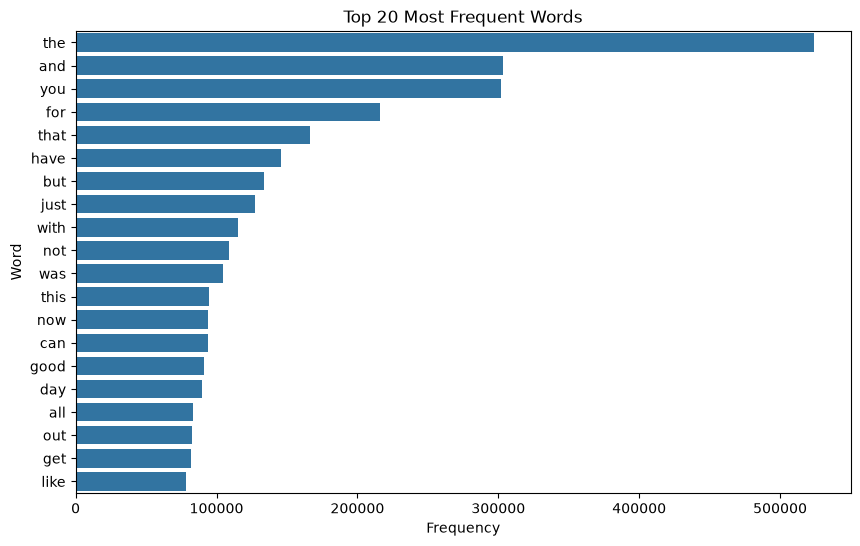

In [10]:
words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=words_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

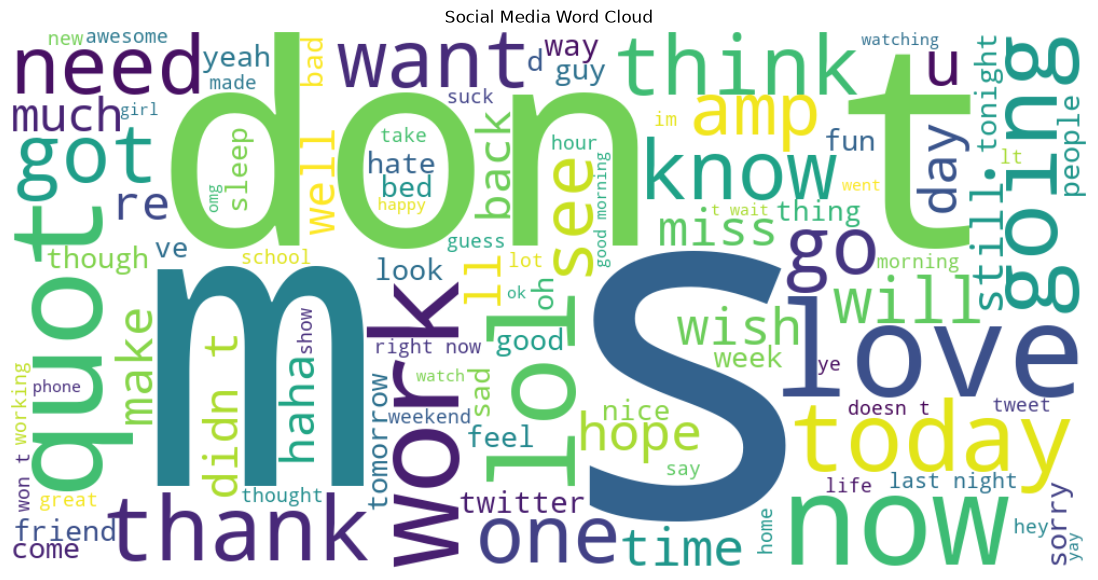

In [11]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(all_words)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Social Media Word Cloud")

plt.show()

In [12]:
def extract_hashtags(text):

    return re.findall(r"#(\w+)", str(text).lower())


hashtags = []

for tweet in df["Tweet"]:
    hashtags.extend(extract_hashtags(tweet))


hashtag_counts = Counter(hashtags)

top_hashtags = hashtag_counts.most_common(20)

print("\nTop 20 Hashtags:")

for hashtag, count in top_hashtags:
    print("#" + hashtag, ":", count)


Top 20 Hashtags:
#followfriday : 2640
#fb : 1786
#ff : 985
#squarespace : 941
#1 : 519
#iranelection : 518
#seb : 499
#musicmonday : 422
#fail : 363
#2 : 341
#asot400 : 333
#iphone : 318
#bsb : 314
#iremember : 299
#myweakness : 272
#marsiscoming : 260
#f1 : 258
#e3 : 257
#bgt : 246
#mcflyforgermany : 230


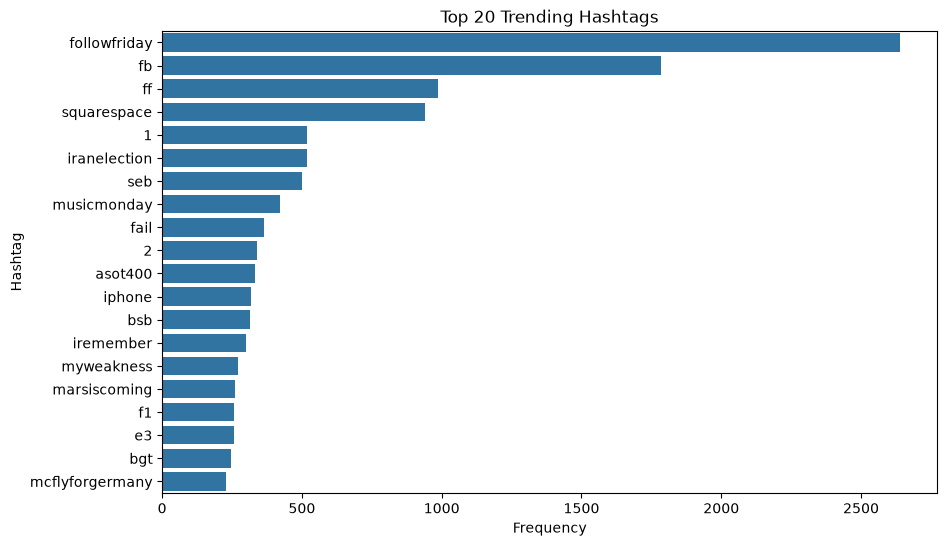

In [13]:

if len(top_hashtags) > 0:

    hashtag_df = pd.DataFrame(
        top_hashtags,
        columns=["Hashtag", "Frequency"]
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=hashtag_df,
        x="Frequency",
        y="Hashtag"
    )

    plt.title("Top 20 Trending Hashtags")
    plt.xlabel("Frequency")
    plt.ylabel("Hashtag")

    plt.show()

In [14]:

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df["Clean_Tweet"]
)

feature_names = vectorizer.get_feature_names_out()

frequencies = X.sum(axis=0).A1

interest_df = pd.DataFrame({
    "Topic": feature_names,
    "Frequency": frequencies
})

interest_df = interest_df.sort_values(
    by="Frequency",
    ascending=False
)

print("\nPublic Interest Topics:")
print(interest_df)


Public Interest Topics:
     Topic  Frequency
7     just     126969
4     good      91343
1      day      89560
9     like      78573
14    quot      72050
17   today      68223
19    work      64953
11    love      64698
3    going      64632
5      got      61445
10     lol      59272
16    time      57958
8     know      52057
6       im      50641
2      don      50384
15  really      50037
0      amp      48686
13   night      43945
12     new      42447
18    want      42302


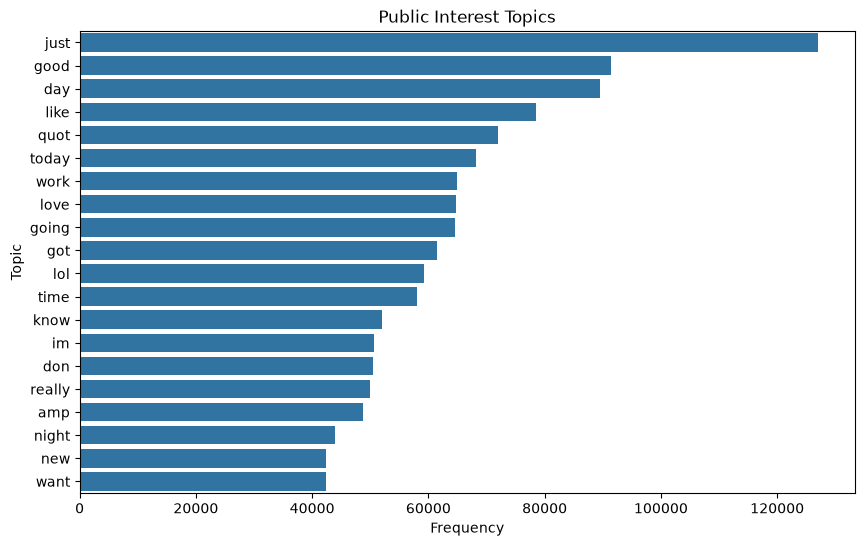

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=interest_df,
    x="Frequency",
    y="Topic"
)

plt.title("Public Interest Topics")
plt.xlabel("Frequency")
plt.ylabel("Topic")

plt.show()


In [17]:

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

bigram_corpus = df["Clean_Tweet"]

if len(bigram_corpus) > 50000:
    bigram_corpus = bigram_corpus.sample(50000, random_state=42)

bigram_matrix = bigram_vectorizer.fit_transform(
    bigram_corpus
)

bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_frequency = bigram_matrix.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "Topic": bigram_names,
    "Frequency": bigram_frequency
})

bigram_df = bigram_df.sort_values(
    by="Frequency",
    ascending=False
)

print("\nTop Trending Two-Word Topics:")
print(bigram_df)


Top Trending Two-Word Topics:
              Topic  Frequency
12         just got        373
9      good morning        328
0          don know        196
4         feel like        192
15  looking forward        180
16       looks like        169
5     getting ready        147
10       good night        146
2          don want        145
8         good luck        143
7          good day        137
6         going bed        122
19           ve got        119
11   happy birthday        115
17        quot quot        112
18      sounds like        111
3       feel better        110
1          don like        108
14         let know        108
13        just woke        108


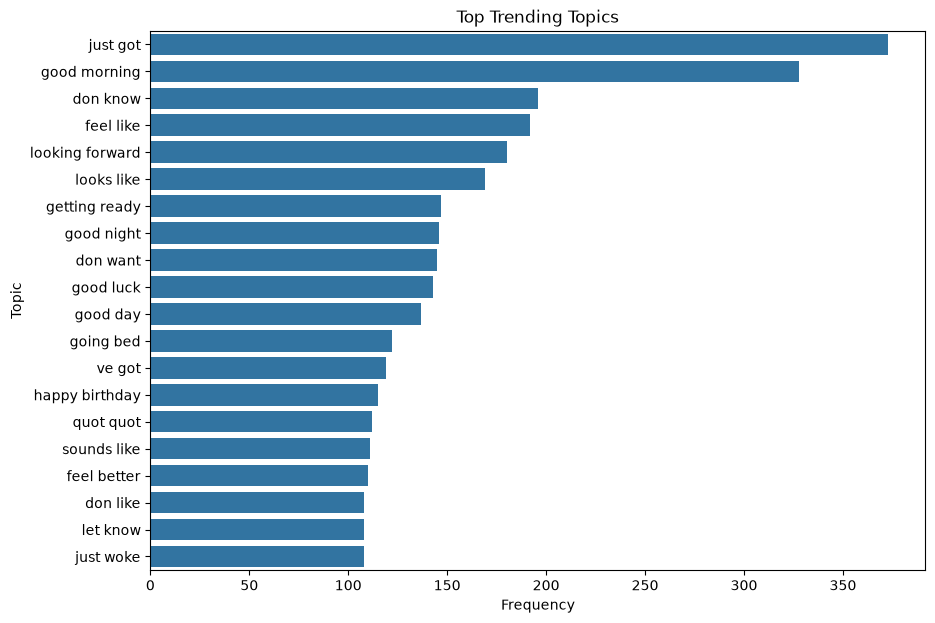

In [18]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=bigram_df,
    x="Frequency",
    y="Topic"
)

plt.title("Top Trending Topics")
plt.xlabel("Frequency")
plt.ylabel("Topic")

plt.show()


Top 10 Most Active Users:
User
lost_dog           549
webwoke            345
tweetpet           310
SallytheShizzle    281
VioletsCRUK        279
mcraddictal        273
tsarnick           248
what_bugs_u        246
Karen230683        238
DarkPiano          236
Name: count, dtype: int64


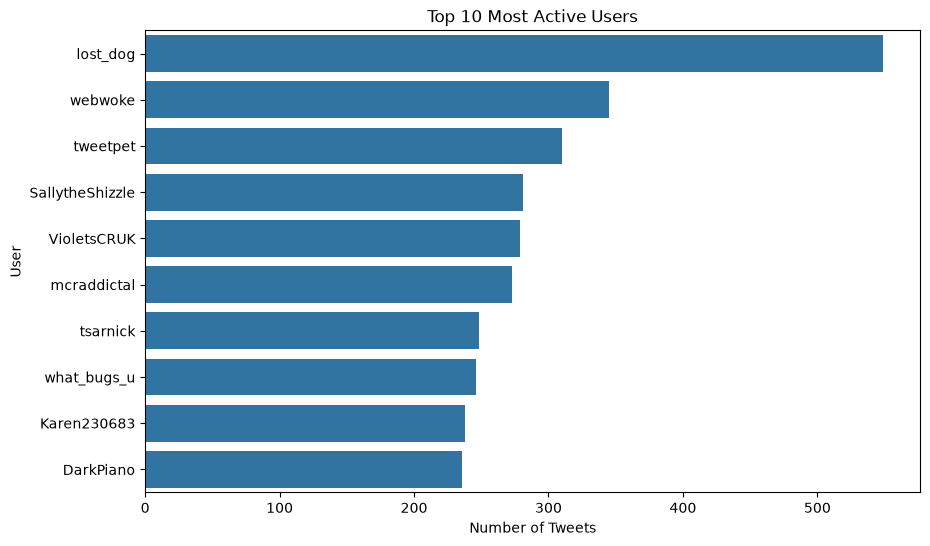

In [19]:
top_users = df["User"].value_counts().head(10)

print("\nTop 10 Most Active Users:")
print(top_users)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_users.values,
    y=top_users.index
)

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Tweets")
plt.ylabel("User")

plt.show()


In [20]:
output_file = "social_media_cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nCleaned dataset saved as:", output_file)


Cleaned dataset saved as: social_media_cleaned.csv


In [21]:
bigram_df.to_csv(
    "trending_topics.csv",
    index=False
)

interest_df.to_csv(
    "public_interest_topics.csv",
    index=False
)

print("Trending topics saved.")
print("Public interest topics saved.")

Trending topics saved.
Public interest topics saved.
